VISUALIZATIONS NEEDED:

1. Apple raw prices over 5 years
2. Apple with SMAs over 5 years
3. Seven tech stocks, raw prices
4. Seven tech stocks, relative changes over 1 year
5. Seven tech stocks, relative changes over 5 years
6. Seven tech stocks, positive prob. the day after n-percent positive change
7. Seven tech stocks, negative prob. the day after n-percent negative change
8. Seven tech stocks, positive prob. the day after n-consecutive positive days
9. Seven tech stocks, negative prob. the day after n-consecutive negative days
10. Collinearity for all stocks
11. Collinearity just for the seven tech stocks
12. Which stocks improved most on the final day
13. Final day improvement, with 5b market cap filter
14. Which stocks improved most over the entire dataset
15. Whole dataset improvement, with 5b market cap filter

In [42]:
import pandas as pd

price_df = pd.read_parquet('daily_cleaned_price_data.parquet')
metadata_df = pd.read_parquet('daily_cleaned_metadata.parquet')

df = price_df.merge(
     metadata_df,
     on='ticker',
     how='left'
)

df

,timestamp,ticker,open,high,low,close,volume,vwap,transactions,name,market_cap,exchange,country
0,2021-05-24,A,133.51,134.41,132.5300,133.34,1.325305e+06,133.6936,18683.0,Agilent Technologies Inc.,3.215449e+10,XNYS,us
1,2021-05-25,A,133.41,134.80,133.0100,133.23,1.905708e+06,133.6992,26967.0,Agilent Technologies Inc.,3.215449e+10,XNYS,us
2,2021-05-26,A,136.30,138.00,133.2505,133.29,2.530998e+06,134.5671,31259.0,Agilent Technologies Inc.,3.215449e+10,XNYS,us
3,2021-05-27,A,133.32,138.14,133.1600,137.54,3.720923e+06,137.2590,37177.0,Agilent Technologies Inc.,3.215449e+10,XNYS,us
4,2021-05-28,A,138.60,139.21,138.0001,138.13,1.289049e+06,138.4188,20108.0,Agilent Technologies Inc.,3.215449e+10,XNYS,us
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3493827,2026-05-15,ZYME,24.50,25.34,23.6346,23.93,6.407959e+05,23.8908,11366.0,Zymeworks Inc.,1.827577e+09,XNAS,us
3493828,2026-05-18,ZYME,23.93,24.70,23.8800,24.43,7.502414e+05,24.3372,14709.0,Zymeworks Inc.,1.827577e+09,XNAS,us
3493829,2026-05-19,ZYME,24.19,24.55,23.8700,24.40,6.153201e+05,24.3494,12503.0,Zymeworks Inc.,1.827577e+09,XNAS,us
3493830,2026-05-20,ZYME,24.40,25.20,24.2650,24.84,5.426638e+05,24.8734,13051.0,Zymeworks Inc.,1.827577e+09,XNAS,us


In [43]:
SMA_thresholds = 10, 20, 50, 100

for threshold in SMA_thresholds:
    df[f'SMA{threshold}'] = (
        df.groupby('ticker')['close']
        .transform(lambda x: x.rolling(threshold).mean())
    )

In [44]:
df['pct_change_from_prev'] = (
    df.groupby('ticker')['close']
    .pct_change() * 100
)

df['next_close_pct_change'] = (
    (
        df.groupby('ticker')['close']
        .shift(-1)
        / df['close']
    - 1
    ) * 100
)


df['close_pct_of_day1'] = (
    df.groupby('ticker')['close']
    .transform(lambda x: (x / x.iloc[0]) * 100)
)

In [45]:
df

,timestamp,ticker,open,high,low,close,volume,vwap,transactions,name,market_cap,exchange,country,SMA10,SMA20,SMA50,SMA100,pct_change_from_prev,next_close_pct_change,close_pct_of_day1
0,2021-05-24,A,133.51,134.41,132.5300,133.34,1.325305e+06,133.6936,18683.0,Agilent Technologies Inc.,3.215449e+10,XNYS,us,NaN,NaN,NaN,NaN,NaN,-0.082496,100.000000
1,2021-05-25,A,133.41,134.80,133.0100,133.23,1.905708e+06,133.6992,26967.0,Agilent Technologies Inc.,3.215449e+10,XNYS,us,NaN,NaN,NaN,NaN,-0.082496,0.045035,99.917504
2,2021-05-26,A,136.30,138.00,133.2505,133.29,2.530998e+06,134.5671,31259.0,Agilent Technologies Inc.,3.215449e+10,XNYS,us,NaN,NaN,NaN,NaN,0.045035,3.188536,99.962502
3,2021-05-27,A,133.32,138.14,133.1600,137.54,3.720923e+06,137.2590,37177.0,Agilent Technologies Inc.,3.215449e+10,XNYS,us,NaN,NaN,NaN,NaN,3.188536,0.428966,103.149843
4,2021-05-28,A,138.60,139.21,138.0001,138.13,1.289049e+06,138.4188,20108.0,Agilent Technologies Inc.,3.215449e+10,XNYS,us,NaN,NaN,NaN,NaN,0.428966,-0.673279,103.592320
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3493827,2026-05-15,ZYME,24.50,25.34,23.6346,23.93,6.407959e+05,23.8908,11366.0,Zymeworks Inc.,1.827577e+09,XNAS,us,25.195,26.5305,25.6757,24.81475,-0.125209,2.089427,82.975035
3493828,2026-05-18,ZYME,23.93,24.70,23.8800,24.43,7.502414e+05,24.3372,14709.0,Zymeworks Inc.,1.827577e+09,XNAS,us,24.960,26.3595,25.6827,24.78285,2.089427,-0.122800,84.708738
3493829,2026-05-19,ZYME,24.19,24.55,23.8700,24.40,6.153201e+05,24.3494,12503.0,Zymeworks Inc.,1.827577e+09,XNAS,us,24.732,26.1660,25.6857,24.75895,-0.122800,1.803279,84.604716
3493830,2026-05-20,ZYME,24.40,25.20,24.2650,24.84,5.426638e+05,24.8734,13051.0,Zymeworks Inc.,1.827577e+09,XNAS,us,24.455,25.9815,25.6733,24.73875,1.803279,1.086957,86.130374


In [46]:
# Ensure timestamp
df['timestamp'] = pd.to_datetime(df['timestamp'])


# Calculate SMAs
SMA_thresholds = 10, 20, 50, 100

for threshold in SMA_thresholds:
    df[f'SMA{threshold}'] = (
        df.groupby('ticker')['close']
        .transform(lambda x: x.rolling(threshold).mean())
    )


# Pct change from previous day and to next day
df['pct_change_from_prev'] = (
    df.groupby('ticker')['close']
    .pct_change() * 100
)

df['next_close_pct_change'] = (
    (
        df.groupby('ticker')['close']
        .shift(-1)
        / df['close']
    - 1
    ) * 100
)


# MOST ADDITIONAL METRICS, IF ANY, CAN BE DONE AROUND HERE


# Create dataframes covering different timespans
# Will also create variations dropping nulls

from dateutil.relativedelta import relativedelta
import pandas as pd

# Ensure datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

max_date = df['timestamp'].max()

year_thresholds = [1, 2, 5]

# Master dictionary to store all created dfs
dfs = {}

for years in year_thresholds:

    # Main dataframe
    df_name = f'df_daily_{years}_yr'

    dfs[df_name] = (
        df[
            df['timestamp'] >= max_date - relativedelta(years=years)
        ].copy()
    )

    # Also create standalone variable
    globals()[df_name] = dfs[df_name]

    print(df_name)
    print(dfs[df_name].shape)

    # Create no-null version only if nulls exist
    if dfs[df_name].isnull().values.any():

        no_null_name = f'{df_name}_no_null'

        dfs[no_null_name] = (
            dfs[df_name]
            .dropna()
            .copy()
        )

        # Also create standalone variable
        globals()[no_null_name] = dfs[no_null_name]

        print(no_null_name)
        print(dfs[no_null_name].shape)



# For each of the created dataframes, calculate change from day one
# This has to be done last as dataframes now have different start days
for name, df in dfs.items():
    df['close_pct_of_day1'] = (df.groupby('ticker')['close'].transform(lambda x: (x / x.iloc[0]) * 100))

df_daily_1_yr
(701568, 20)
df_daily_1_yr_no_null
(698784, 20)
df_daily_2_yr
(1397568, 20)
df_daily_2_yr_no_null
(1394784, 20)
df_daily_5_yr
(3493832, 20)
df_daily_5_yr_no_null
(3215432, 20)


In [47]:
df_daily_5_yr

,timestamp,ticker,open,high,low,close,volume,vwap,transactions,name,market_cap,exchange,country,SMA10,SMA20,SMA50,SMA100,pct_change_from_prev,next_close_pct_change,close_pct_of_day1
0,2021-05-24,A,133.51,134.41,132.5300,133.34,1.325305e+06,133.6936,18683.0,Agilent Technologies Inc.,3.215449e+10,XNYS,us,NaN,NaN,NaN,NaN,NaN,-0.082496,100.000000
1,2021-05-25,A,133.41,134.80,133.0100,133.23,1.905708e+06,133.6992,26967.0,Agilent Technologies Inc.,3.215449e+10,XNYS,us,NaN,NaN,NaN,NaN,-0.082496,0.045035,99.917504
2,2021-05-26,A,136.30,138.00,133.2505,133.29,2.530998e+06,134.5671,31259.0,Agilent Technologies Inc.,3.215449e+10,XNYS,us,NaN,NaN,NaN,NaN,0.045035,3.188536,99.962502
3,2021-05-27,A,133.32,138.14,133.1600,137.54,3.720923e+06,137.2590,37177.0,Agilent Technologies Inc.,3.215449e+10,XNYS,us,NaN,NaN,NaN,NaN,3.188536,0.428966,103.149843
4,2021-05-28,A,138.60,139.21,138.0001,138.13,1.289049e+06,138.4188,20108.0,Agilent Technologies Inc.,3.215449e+10,XNYS,us,NaN,NaN,NaN,NaN,0.428966,-0.673279,103.592320
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3493827,2026-05-15,ZYME,24.50,25.34,23.6346,23.93,6.407959e+05,23.8908,11366.0,Zymeworks Inc.,1.827577e+09,XNAS,us,25.195,26.5305,25.6757,24.81475,-0.125209,2.089427,82.975035
3493828,2026-05-18,ZYME,23.93,24.70,23.8800,24.43,7.502414e+05,24.3372,14709.0,Zymeworks Inc.,1.827577e+09,XNAS,us,24.960,26.3595,25.6827,24.78285,2.089427,-0.122800,84.708738
3493829,2026-05-19,ZYME,24.19,24.55,23.8700,24.40,6.153201e+05,24.3494,12503.0,Zymeworks Inc.,1.827577e+09,XNAS,us,24.732,26.1660,25.6857,24.75895,-0.122800,1.803279,84.604716
3493830,2026-05-20,ZYME,24.40,25.20,24.2650,24.84,5.426638e+05,24.8734,13051.0,Zymeworks Inc.,1.827577e+09,XNAS,us,24.455,25.9815,25.6733,24.73875,1.803279,1.086957,86.130374


# 1. Apple raw prices over 5 years


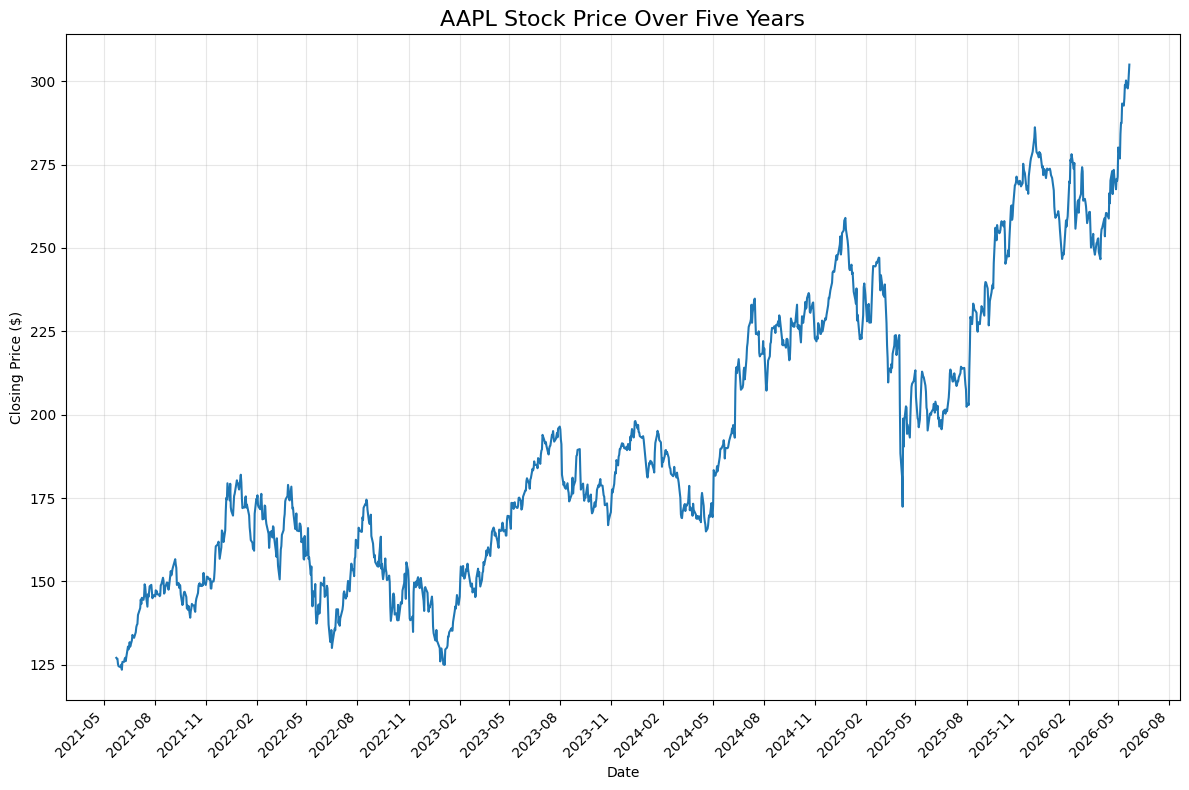

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Filter to AAPL and make a copy
aapl_df = df[
    df['ticker'] == 'AAPL'
].copy()

# Ensure timestamp is datetime and observations are chronological
aapl_df['timestamp'] = pd.to_datetime(aapl_df['timestamp'])
aapl_df = aapl_df.sort_values('timestamp')

# Create visualization
fig1, ax1 = plt.subplots(figsize=(12, 8))

ax1.plot(
    aapl_df['timestamp'],
    aapl_df['close'],
    linewidth=1.5
)

ax1.set_title('AAPL Stock Price Over Five Years', fontsize=16)
ax1.set_xlabel('Date')
ax1.set_ylabel('Closing Price ($)')

# Show one label every three months
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.setp(
    ax1.get_xticklabels(),
    rotation=45,
    ha='right'
)

ax1.grid(alpha=0.3)

fig1.tight_layout()

# # Save before displaying
# fig1.savefig(
#     'aapl_stock_price_five_years.png',
#     dpi=300,
#     bbox_inches='tight'
# )

fig1.savefig('v1_aapl_price.png', dpi=300, bbox_inches='tight')

plt.show()

# 2 - AAPL plus SMAs

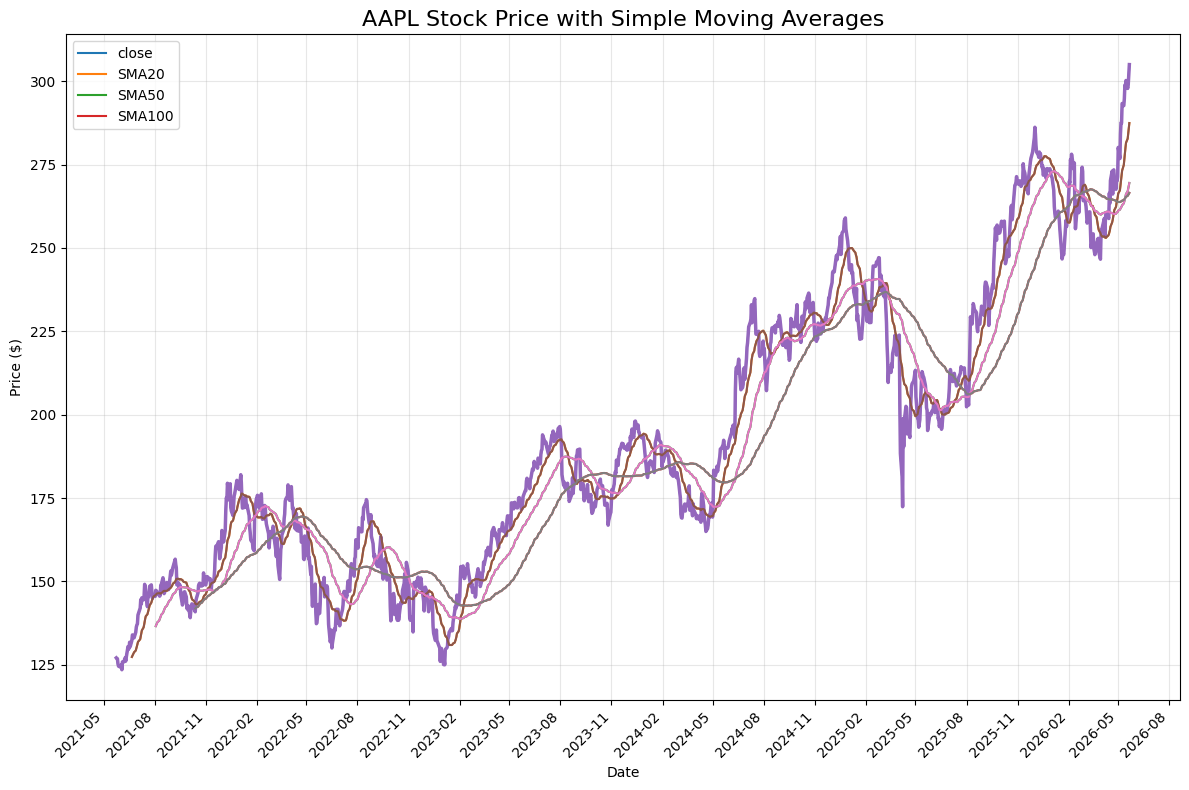

In [25]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

features_to_plot = ['close', 'SMA20', 'SMA50', 'SMA100']

fig2, ax2 = plt.subplots(figsize=(12, 8))

# Ensure chronological order
aapl_df = aapl_df.sort_values('timestamp')

for feature in features_to_plot:
    ax2.plot(
        aapl_df['timestamp'],
        aapl_df[feature],
        label=feature,
        linewidth=1.5
    )

ax2.set_title('AAPL Stock Price with Simple Moving Averages', fontsize=16)
ax2.set_xlabel('Date')
ax2.set_ylabel('Price ($)')

ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.setp(ax2.get_xticklabels(), rotation=45, ha='right')

ax2.legend()
ax2.grid(alpha=0.3)

fig2.tight_layout()


fig2.savefig(
    'v2_appl_with_smas.png',
    dpi=300,
    bbox_inches='tight'
)



plt.show()

# 3. Seven tech stocks, absolute prices


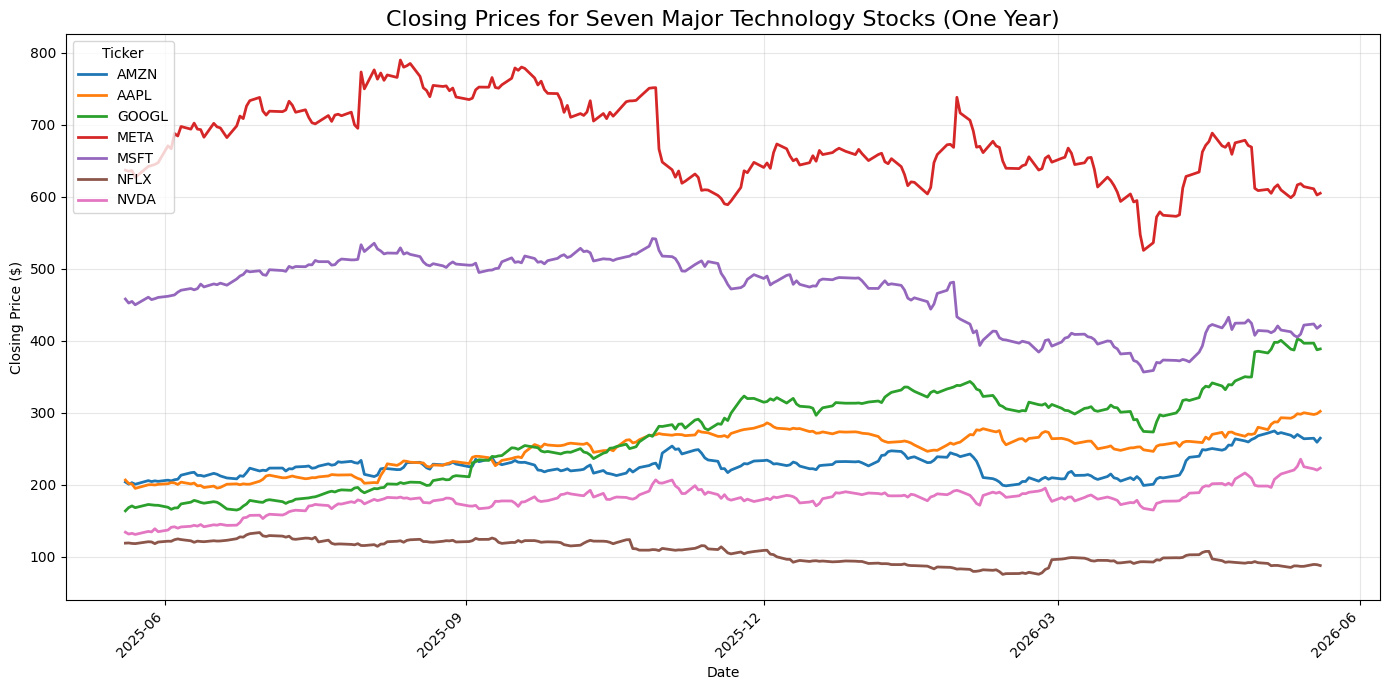

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Stocks to plot
tech_stocks = ['AMZN', 'AAPL', 'GOOGL', 'META', 'MSFT', 'NFLX', 'NVDA']

# Data
master_df = df_daily_1_yr.copy()
master_df['timestamp'] = pd.to_datetime(master_df['timestamp'])

# Create figure
fig, ax = plt.subplots(figsize=(14, 7))

# Plot each stock
for stock in tech_stocks:
    stock_df = (
        master_df[master_df['ticker'] == stock]
        .sort_values('timestamp')
    )

    ax.plot(
        stock_df['timestamp'],
        stock_df['close'],
        label=stock,
        linewidth=2
    )

# Labels and title
ax.set_xlabel('Date')
ax.set_ylabel('Closing Price ($)')

ax.set_title(
    'Closing Prices for Seven Major Technology Stocks (One Year)',
    fontsize=16
)

# Date formatting
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

# Legend and grid
ax.legend(title='Ticker')
ax.grid(alpha=0.3)

fig.tight_layout()

# Save figure
fig.savefig(
    'v3_tech_absolute.png',
    dpi=300,
    bbox_inches='tight'
)

# Display
plt.show()

# 4. Seven tech stocks, relative prices over 1 year

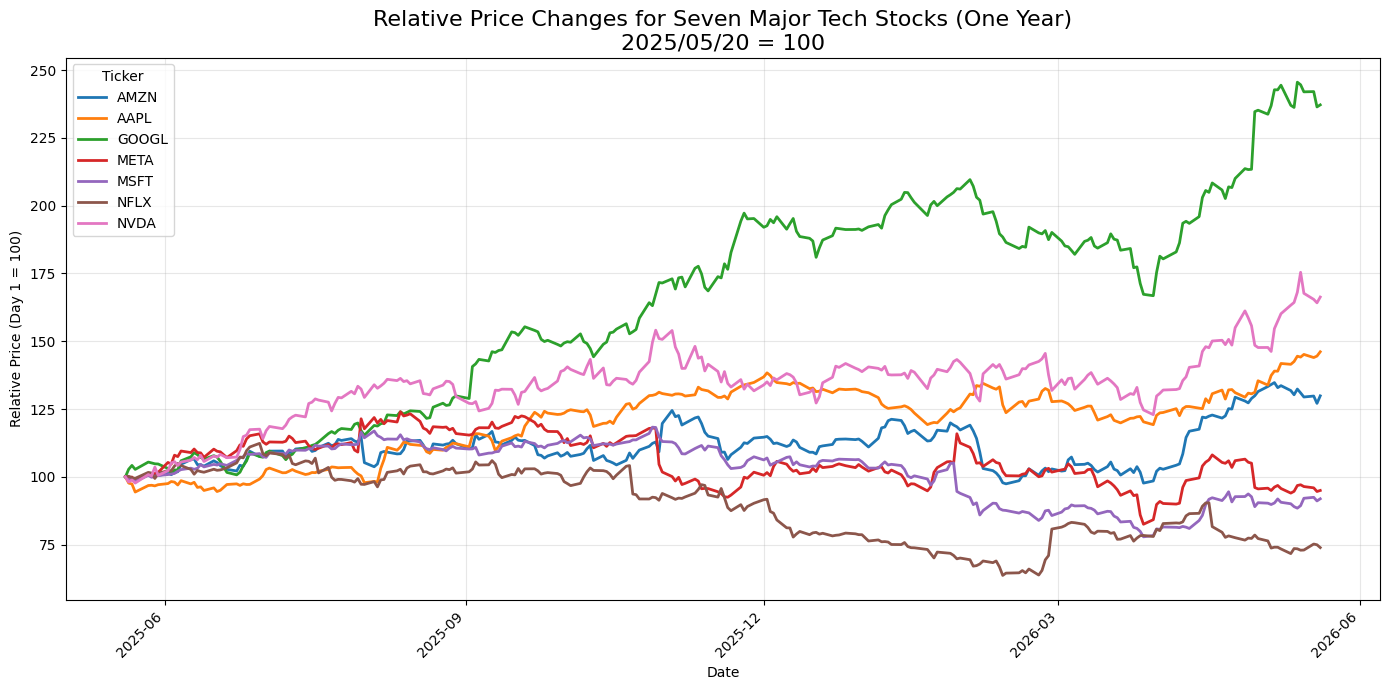

In [36]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

tech_stocks = ['AMZN', 'AAPL', 'GOOGL', 'META', 'MSFT', 'NFLX', 'NVDA']

master_df = df_daily_1_yr.copy()
master_df['timestamp'] = pd.to_datetime(master_df['timestamp'])

fig, ax = plt.subplots(figsize=(14, 7))

for stock in tech_stocks:
    stock_df = (
        master_df[master_df['ticker'] == stock]
        .sort_values('timestamp')
    )

    ax.plot(
        stock_df['timestamp'],
        stock_df['close_pct_of_day1'],
        label=stock,
        linewidth=2
    )

ax.set_xlabel('Date')
ax.set_ylabel('Relative Price (Day 1 = 100)')
ax.set_title(
    'Relative Price Changes for Seven Major Tech Stocks (One Year)\n'
    f'{master_df["timestamp"].min():%Y/%m/%d} = 100',
    fontsize=16
)

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

ax.legend(title='Ticker')
ax.grid(alpha=0.3)

fig.tight_layout()

fig.savefig(
    'v4_tech_relative_1yr.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# 5. Tech stocks, relative prices over 5 years

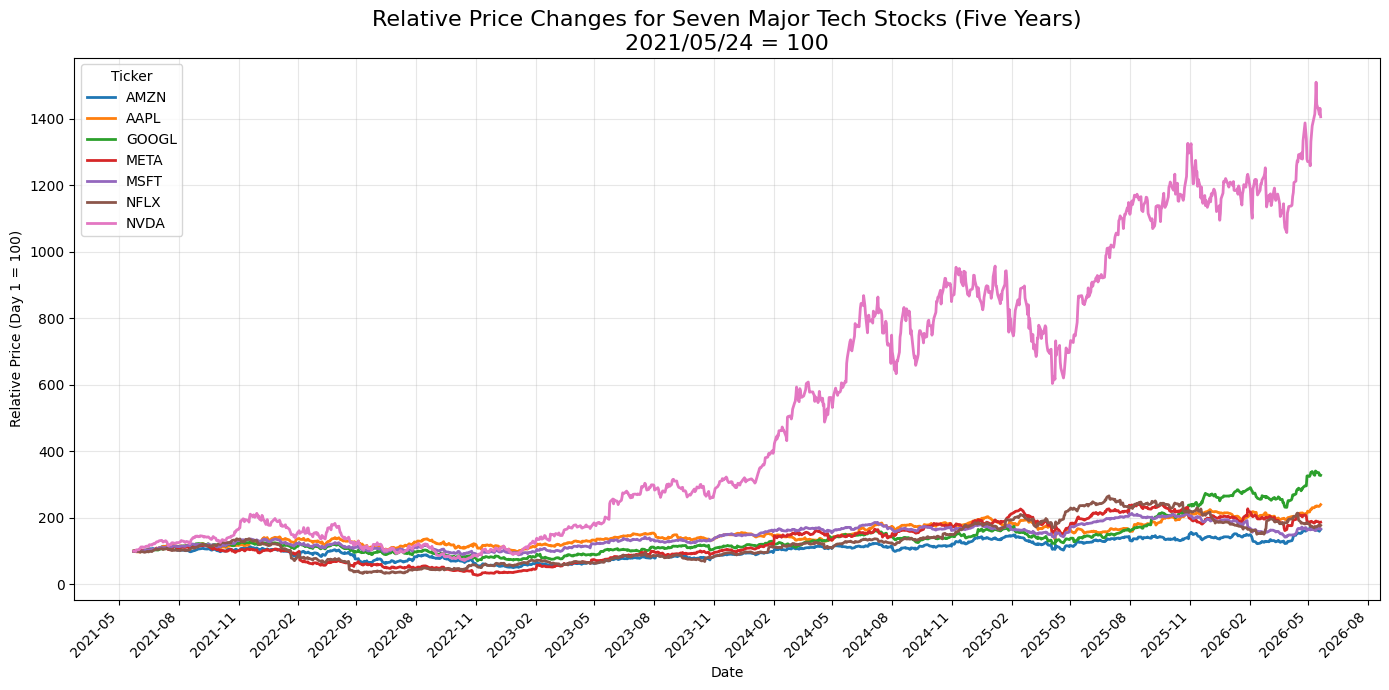

In [49]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

tech_stocks = ['AMZN', 'AAPL', 'GOOGL', 'META', 'MSFT', 'NFLX', 'NVDA']

master_df = df_daily_5_yr.copy()
master_df['timestamp'] = pd.to_datetime(master_df['timestamp'])

fig, ax = plt.subplots(figsize=(14, 7))

for stock in tech_stocks:
    stock_df = (
        master_df[master_df['ticker'] == stock]
        .sort_values('timestamp')
    )

    ax.plot(
        stock_df['timestamp'],
        stock_df['close_pct_of_day1'],
        label=stock,
        linewidth=2
    )

ax.set_xlabel('Date')
ax.set_ylabel('Relative Price (Day 1 = 100)')
ax.set_title(
    'Relative Price Changes for Seven Major Tech Stocks (Five Years)\n'
    f'{master_df["timestamp"].min():%Y/%m/%d} = 100',
    fontsize=16
)

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

ax.legend(title='Ticker')
ax.grid(alpha=0.3)

fig.tight_layout()

fig.savefig(
    'v5_tech_relative_5yr.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# 6. Seven tech stocks, positive prob. the day after n-percent positive change

In [50]:
ticker_list = ['AAPL', 'NVDA', 'NFLX', 'AMZN', 'GOOGL', 'META', 'MSFT']

thresholds = 2, 3, 4, 5, 6, 10, 20

master_df = df_daily_5_yr

results = []

for ticker in ticker_list:
    ticker_df = master_df[master_df['ticker'] == ticker]

    for threshold in thresholds:
        prev_change_condition = ticker_df['pct_change_from_prev'] >= threshold
        next_change_condition = ticker_df['next_close_pct_change'] >= 0

        full_condition = prev_change_condition & next_change_condition

        days_w_both_conditions = full_condition.sum()
        days_with_growth_threshold = prev_change_condition.sum()

        if days_with_growth_threshold > 0:
            pos_change_prob = (
                days_w_both_conditions / days_with_growth_threshold
            ) * 100
        else:
            pos_change_prob = None

        results.append({
            'ticker': ticker,
            'pct_increase_threshold': threshold,
            'pos_change_prob': pos_change_prob,
            'days_with_growth_threshold': days_with_growth_threshold,
            'days_w_both_conditions': days_w_both_conditions
        })

change_threshold_df = pd.DataFrame(results)

change_threshold_df

,ticker,pct_increase_threshold,pos_change_prob,days_with_growth_threshold,days_w_both_conditions
0,AAPL,2,53.225806,124,66
1,AAPL,3,50.000000,46,23
2,AAPL,4,42.105263,19,8
3,AAPL,5,62.500000,8,5
4,AAPL,6,66.666667,6,4
5,AAPL,10,0.000000,1,0
6,AAPL,20,NaN,0,0
7,NVDA,2,54.920635,315,173
8,NVDA,3,54.187192,203,110
9,NVDA,4,53.174603,126,67


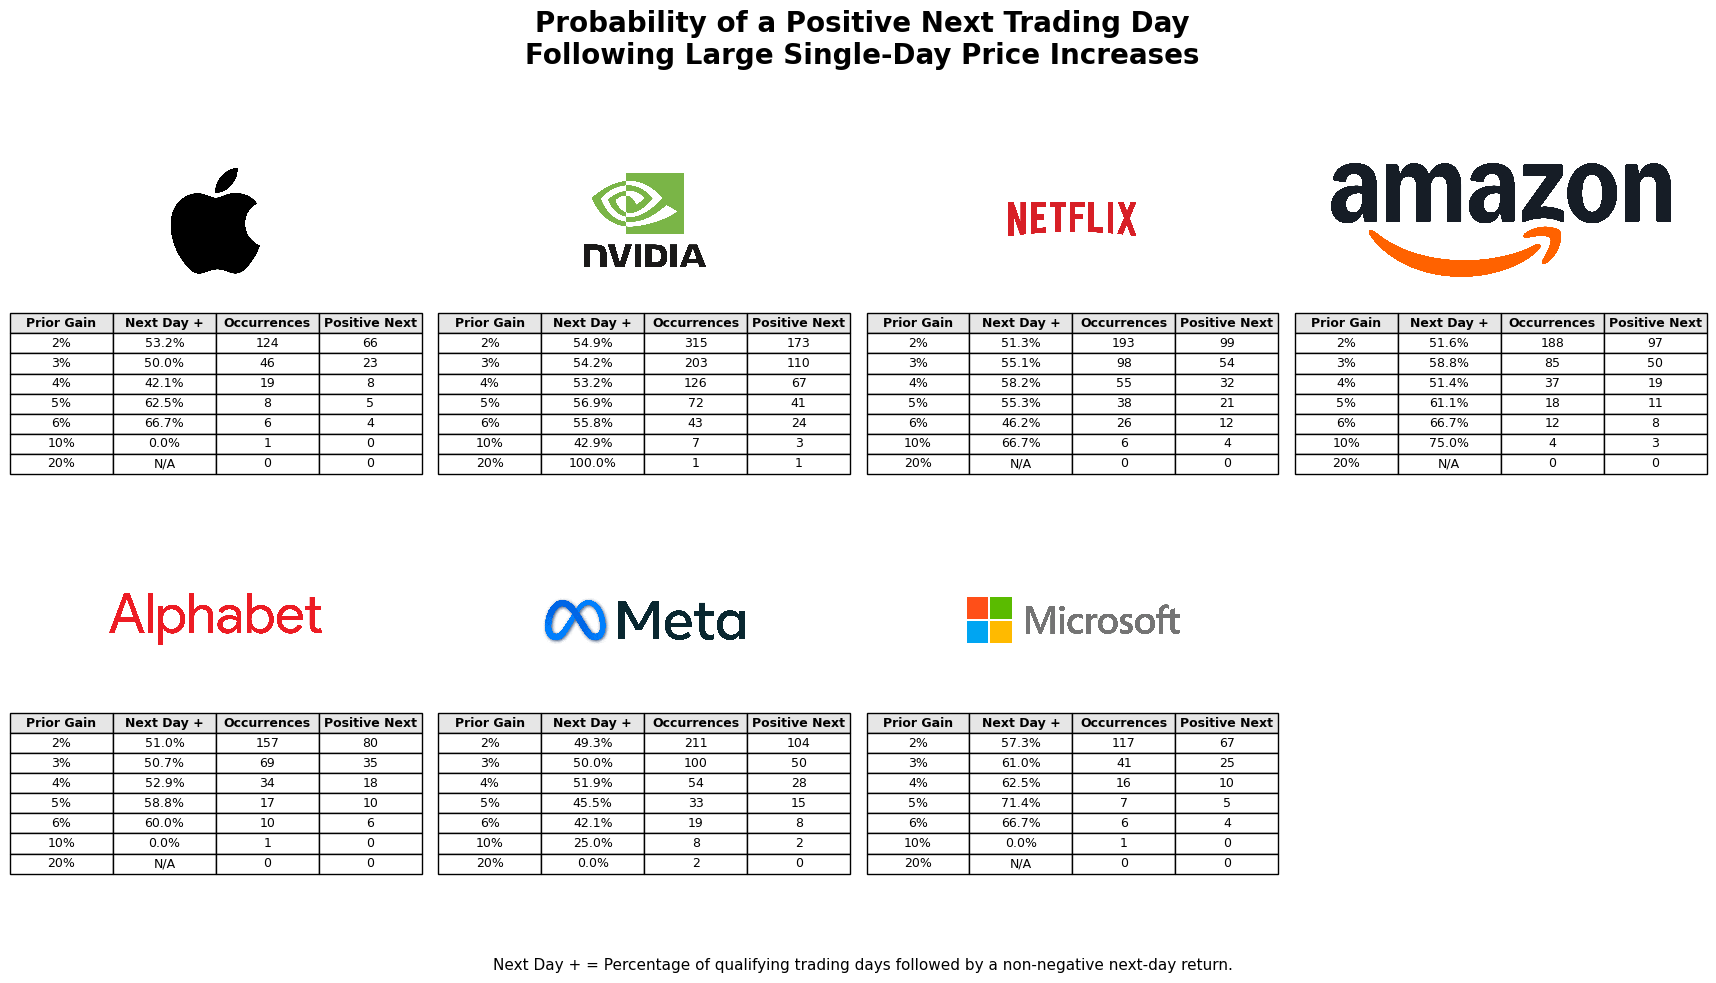

In [58]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

# ---------------------------------------------------------
# Calculate probability tables
# ---------------------------------------------------------

ticker_list = ['AAPL', 'NVDA', 'NFLX', 'AMZN', 'GOOGL', 'META', 'MSFT']

thresholds = [2, 3, 4, 5, 6, 10, 20]

master_df = df_daily_5_yr

results = []

for ticker in ticker_list:
    ticker_df = master_df[master_df['ticker'] == ticker]

    for threshold in thresholds:

        prev_change_condition = (
            ticker_df['pct_change_from_prev'] >= threshold
        )

        next_change_condition = (
            ticker_df['next_close_pct_change'] >= 0
        )

        full_condition = (
            prev_change_condition &
            next_change_condition
        )

        days_with_growth_threshold = prev_change_condition.sum()
        days_w_both_conditions = full_condition.sum()

        if days_with_growth_threshold > 0:
            pos_change_prob = (
                days_w_both_conditions /
                days_with_growth_threshold
            ) * 100
        else:
            pos_change_prob = None

        results.append({
            'ticker': ticker,
            'pct_increase_threshold': threshold,
            'pos_change_prob': pos_change_prob,
            'days_with_growth_threshold': days_with_growth_threshold,
            'days_w_both_conditions': days_w_both_conditions
        })

change_threshold_df = pd.DataFrame(results)

# ---------------------------------------------------------
# Figure settings
# ---------------------------------------------------------

logo_folder = "tech_logos"

fig, axes = plt.subplots(
    nrows=2,
    ncols=4,
    figsize=(18, 10)
)

axes = axes.flatten()

# ---------------------------------------------------------
# Create one table per stock
# ---------------------------------------------------------

for ax, ticker in zip(axes, ticker_list):

    ticker_table = (
        change_threshold_df[
            change_threshold_df['ticker'] == ticker
        ]
        .copy()
        .drop(columns='ticker')
    )

    # Format values for display
    ticker_table['pct_increase_threshold'] = (
        ticker_table['pct_increase_threshold']
        .map(lambda x: f"{x}%")
    )

    ticker_table['pos_change_prob'] = (
        ticker_table['pos_change_prob']
        .map(
            lambda x:
            f"{x:.1f}%"
            if pd.notna(x)
            else "N/A"
        )
    )

    # Shorter column names
    ticker_table = ticker_table.rename(columns={
        'pct_increase_threshold': 'Prior Gain',
        'pos_change_prob': 'Next Day +',
        'days_with_growth_threshold': 'Occurrences',
        'days_w_both_conditions': 'Positive Next'
    })

    ax.axis("off")

    # -------------------------------------------------
    # Add company logo
    # -------------------------------------------------

    logo_path = os.path.join(
        logo_folder,
        f"{ticker}.png"
    )

    if os.path.exists(logo_path):

        logo = mpimg.imread(logo_path)

        imagebox = OffsetImage(
            logo,
            zoom=0.04
        )

        ab = AnnotationBbox(
            imagebox,
            (0.5, 1.16),
            xycoords='axes fraction',
            frameon=False
        )

        ax.add_artist(ab)

    # -------------------------------------------------
    # Title
    # -------------------------------------------------

    # TRYING THIS OUT
    # ax.set_title(
    #     ticker,
    #     fontsize=15,
    #     fontweight="bold",
    #     pad=35
    # )

    # -------------------------------------------------
    # Table
    # -------------------------------------------------

    table = ax.table(
        cellText=ticker_table.values,
        colLabels=ticker_table.columns,
        cellLoc="center",
        colLoc="center",
        loc="center"
    )

    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1.1, 1.6)

    # Header formatting
    for col in range(len(ticker_table.columns)):
        header = table[(0, col)]
        header.set_text_props(weight='bold')
        header.set_facecolor('#E6E6E6')

# Hide unused subplot
for ax in axes[len(ticker_list):]:
    ax.axis("off")

# ---------------------------------------------------------
# Overall title
# ---------------------------------------------------------

fig.suptitle(
    "Probability of a Positive Next Trading Day\n"
    "Following Large Single-Day Price Increases",
    fontsize=20,
    fontweight="bold",
    y=0.98
)

fig.text(
    0.5,
    0.02,
    "Next Day + = Percentage of qualifying trading days followed by a non-negative next-day return.",
    ha="center",
    fontsize=11
)

plt.tight_layout(rect=[0.02, 0.05, 0.98, 0.94])

plt.savefig(
    "v6_pos_prob_after_pct_pos.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 7. Seven tech stocks, negative prob. the day after n-percentage negative change.

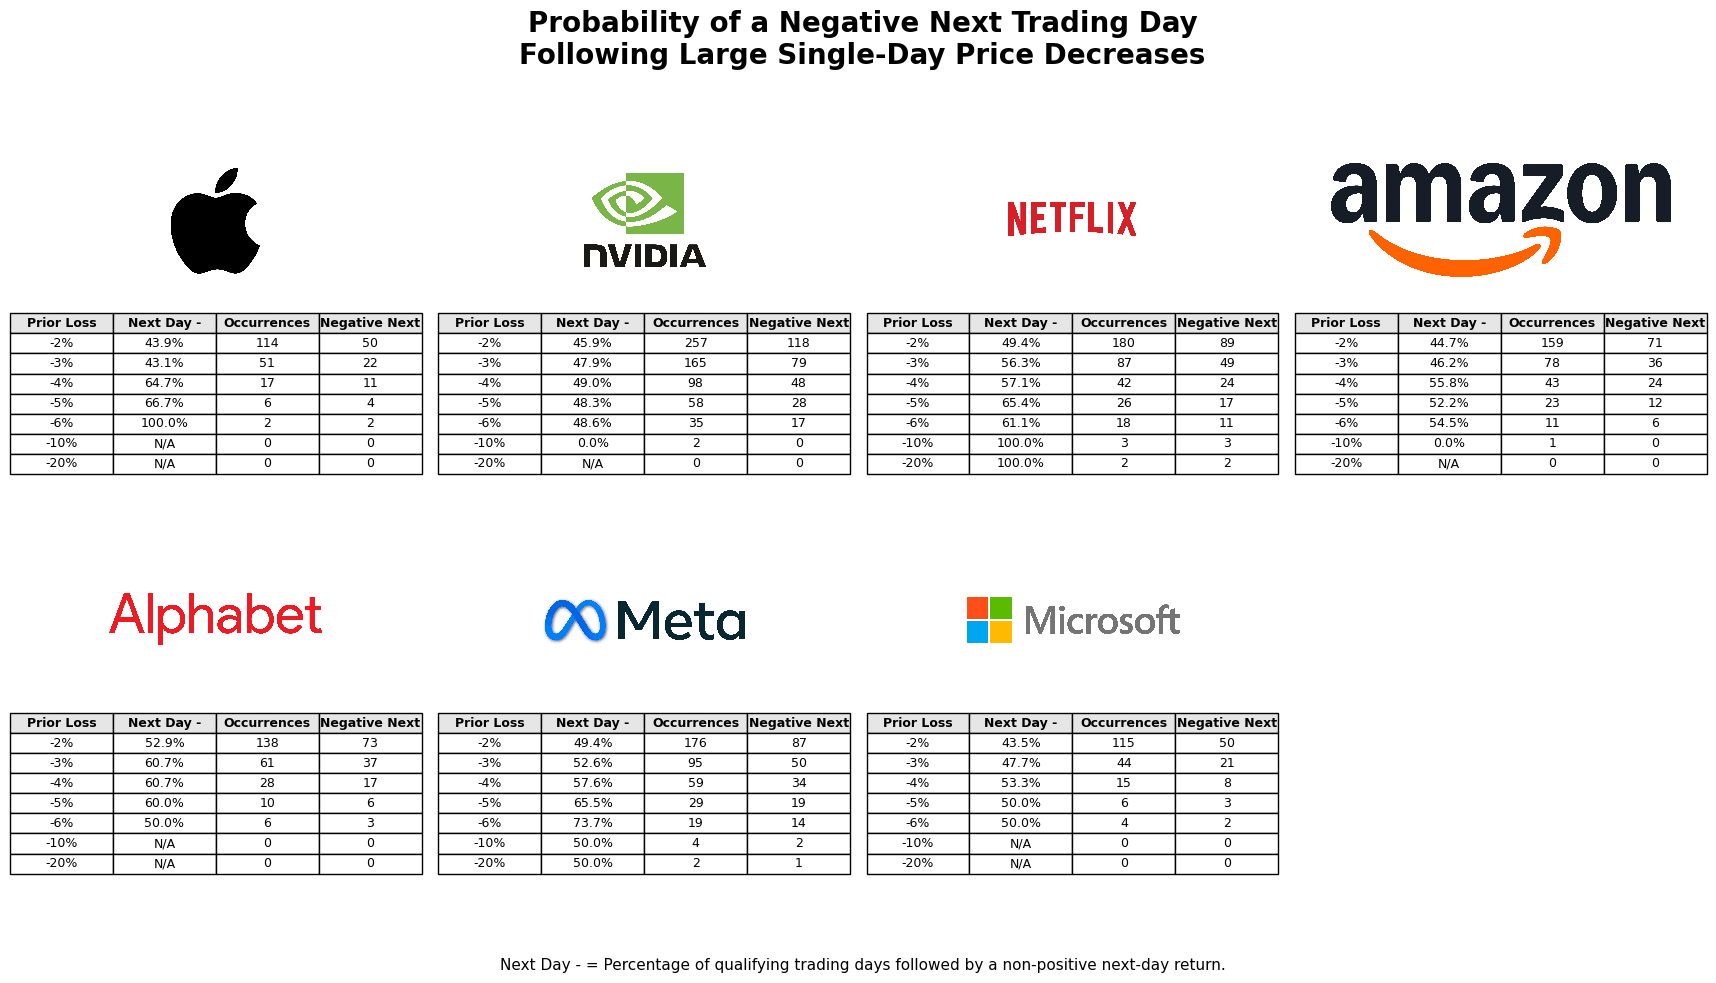

In [61]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

# ---------------------------------------------------------
# Calculate probability tables
# ---------------------------------------------------------

ticker_list = ['AAPL', 'NVDA', 'NFLX', 'AMZN', 'GOOGL', 'META', 'MSFT']

thresholds = [2, 3, 4, 5, 6, 10, 20]

master_df = df_daily_5_yr

results = []

for ticker in ticker_list:
    ticker_df = master_df[master_df['ticker'] == ticker]

    for threshold in thresholds:

        prev_change_condition = (
            ticker_df['pct_change_from_prev'] <= -threshold
        )

        next_change_condition = (
            ticker_df['next_close_pct_change'] <= 0
        )

        full_condition = (
            prev_change_condition &
            next_change_condition
        )

        days_with_decline_threshold = prev_change_condition.sum()
        days_w_both_conditions = full_condition.sum()

        if days_with_decline_threshold > 0:
            neg_change_prob = (
                days_w_both_conditions /
                days_with_decline_threshold
            ) * 100
        else:
            neg_change_prob = None

        results.append({
            'ticker': ticker,
            'pct_decrease_threshold': threshold,
            'neg_change_prob': neg_change_prob,
            'days_with_decline_threshold': days_with_decline_threshold,
            'days_w_both_conditions': days_w_both_conditions
        })

change_threshold_df = pd.DataFrame(results)

# ---------------------------------------------------------
# Figure settings
# ---------------------------------------------------------

logo_folder = "tech_logos"

fig, axes = plt.subplots(
    nrows=2,
    ncols=4,
    figsize=(18, 10)
)

axes = axes.flatten()

# ---------------------------------------------------------
# Create one table per stock
# ---------------------------------------------------------

for ax, ticker in zip(axes, ticker_list):

    ticker_table = (
        change_threshold_df[
            change_threshold_df['ticker'] == ticker
        ]
        .copy()
        .drop(columns='ticker')
    )

    # Format values for display
    ticker_table['pct_decrease_threshold'] = (
        ticker_table['pct_decrease_threshold']
        .map(lambda x: f"-{x}%")
    )

    ticker_table['neg_change_prob'] = (
        ticker_table['neg_change_prob']
        .map(
            lambda x:
            f"{x:.1f}%"
            if pd.notna(x)
            else "N/A"
        )
    )

    # Shorter column names
    ticker_table = ticker_table.rename(columns={
        'pct_decrease_threshold': 'Prior Loss',
        'neg_change_prob': 'Next Day -',
        'days_with_decline_threshold': 'Occurrences',
        'days_w_both_conditions': 'Negative Next'
    })

    ax.axis("off")

    # -------------------------------------------------
    # Add company logo
    # -------------------------------------------------

    logo_path = os.path.join(
        logo_folder,
        f"{ticker}.png"
    )

    if os.path.exists(logo_path):

        logo = mpimg.imread(logo_path)

        imagebox = OffsetImage(
            logo,
            zoom=0.04
        )

        ab = AnnotationBbox(
            imagebox,
            (0.5, 1.16),
            xycoords='axes fraction',
            frameon=False
        )

        ax.add_artist(ab)

    # -------------------------------------------------
    # Title
    # -------------------------------------------------

    # ax.set_title(
    #     ticker,
    #     fontsize=15,
    #     fontweight="bold",
    #     pad=35
    # )

    # -------------------------------------------------
    # Table
    # -------------------------------------------------

    table = ax.table(
        cellText=ticker_table.values,
        colLabels=ticker_table.columns,
        cellLoc="center",
        colLoc="center",
        loc="center"
    )

    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1.1, 1.6)

    # Header formatting
    for col in range(len(ticker_table.columns)):
        header = table[(0, col)]
        header.set_text_props(weight='bold')
        header.set_facecolor('#E6E6E6')

# Hide unused subplot
for ax in axes[len(ticker_list):]:
    ax.axis("off")

# ---------------------------------------------------------
# Overall title
# ---------------------------------------------------------

fig.suptitle(
    "Probability of a Negative Next Trading Day\n"
    "Following Large Single-Day Price Decreases",
    fontsize=20,
    fontweight="bold",
    y=0.98
)

fig.text(
    0.5,
    0.02,
    "Next Day - = Percentage of qualifying trading days followed by a non-positive next-day return.",
    ha="center",
    fontsize=11
)

plt.tight_layout(rect=[0.02, 0.05, 0.98, 0.94])

plt.savefig(
    "v7_neg_prob_after_pct_neg.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 8. Seven tech stocks, positive prob. the day after n-consecutive positive days

# 9. Seven tech stocks, negative prob. the day after n-consecutive negative days

# 10. Collinearity for all stocks

Already have this

# 11. Collinearity just for the seven tech stocks


Already have this

# 12. Which stocks improved most on the final day?

Another dataframe I don't feel like doing.

# 13. Final day improvement, with 5b market cap filter

Yet another.

# 14. Which stocks improved most over the entire dataset


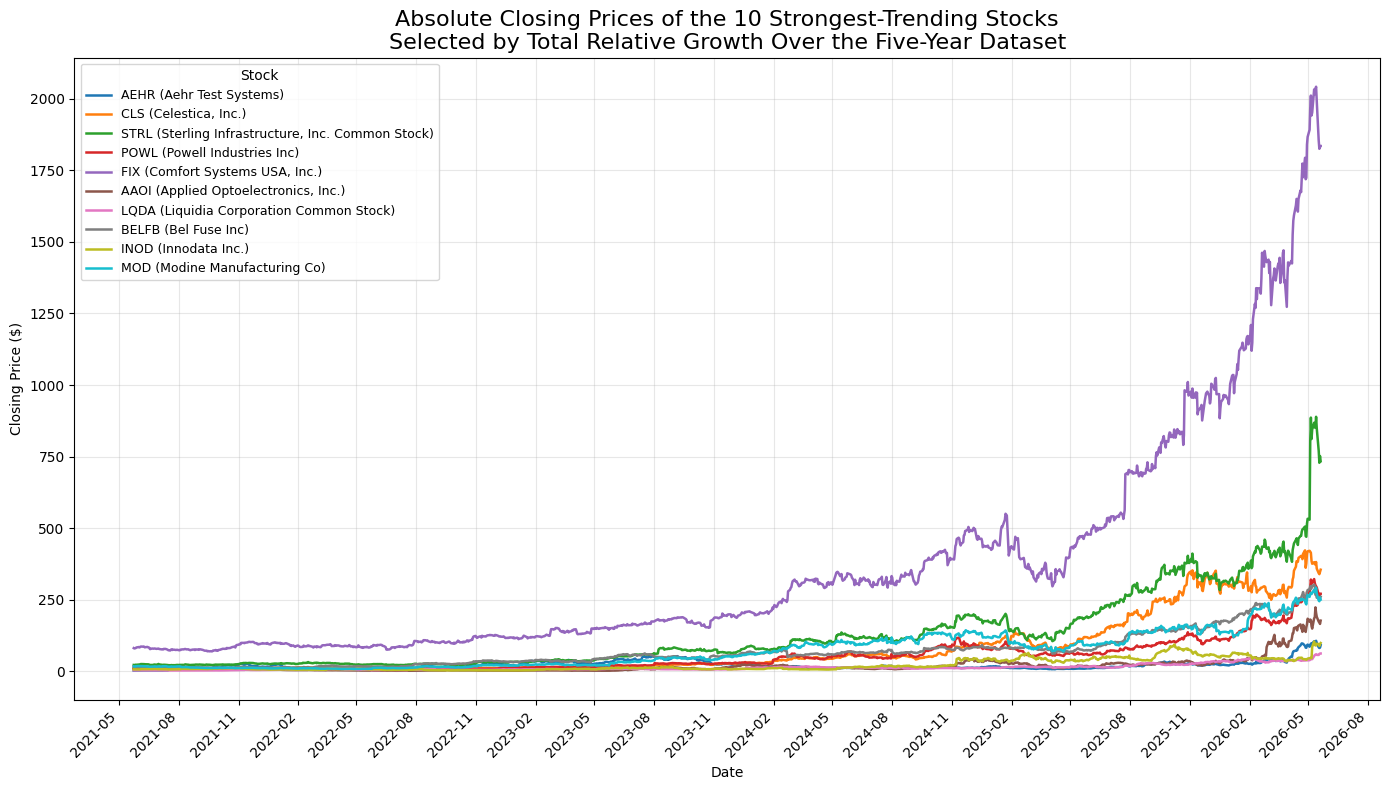

In [69]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Prepare data
master_df = df_daily_5_yr.copy()
master_df['timestamp'] = pd.to_datetime(master_df['timestamp'])
master_df = master_df.sort_values(['ticker', 'timestamp'])

# Find the final date in the dataset
latest_date = master_df['timestamp'].max()

# Get each stock's row on the final date
recent_day_df = master_df[
    master_df['timestamp'] == latest_date
].copy()

# Select the 10 stocks with the greatest relative growth
strongest_df = recent_day_df.nlargest(
    10,
    'close_pct_of_day1'
)

plot_stocks = strongest_df['ticker'].tolist()

# Create ticker-to-company-name dictionary
ticker_to_name = (
    master_df[['ticker', 'name']]
    .drop_duplicates(subset='ticker')
    .set_index('ticker')['name']
    .to_dict()
)

# Create figure
fig, ax = plt.subplots(figsize=(14, 8))

# Plot absolute closing prices
for stock in plot_stocks:
    stock_df = master_df[
        master_df['ticker'] == stock
    ].sort_values('timestamp')

    ax.plot(
        stock_df['timestamp'],
        stock_df['close'],
        label=f'{stock} ({ticker_to_name.get(stock, "Unknown")})',
        linewidth=1.8
    )

# Labels and title
ax.set_xlabel('Date')
ax.set_ylabel('Closing Price ($)')
ax.set_title(
    'Absolute Closing Prices of the 10 Strongest-Trending Stocks\n'
    'Selected by Total Relative Growth Over the Five-Year Dataset',
    fontsize=16
)

# Format dates
ax.xaxis.set_major_locator(
    mdates.MonthLocator(interval=3)
)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter('%Y-%m')
)

plt.setp(
    ax.get_xticklabels(),
    rotation=45,
    ha='right'
)

# Legend and grid
ax.legend(
    title='Stock',
    loc='best',
    fontsize=9
)

ax.grid(alpha=0.3)

fig.tight_layout()

# Save image
fig.savefig(
    'v14_overall_improvement_top10.png',
    dpi=300,
    bbox_inches='tight'
)

# Display image
plt.show()

In [63]:
df_daily_5_yr

,timestamp,ticker,open,high,low,close,volume,vwap,transactions,name,market_cap,exchange,country,SMA10,SMA20,SMA50,SMA100,pct_change_from_prev,next_close_pct_change,close_pct_of_day1
0,2021-05-24,A,133.51,134.41,132.5300,133.34,1.325305e+06,133.6936,18683.0,Agilent Technologies Inc.,3.215449e+10,XNYS,us,NaN,NaN,NaN,NaN,NaN,-0.082496,100.000000
1,2021-05-25,A,133.41,134.80,133.0100,133.23,1.905708e+06,133.6992,26967.0,Agilent Technologies Inc.,3.215449e+10,XNYS,us,NaN,NaN,NaN,NaN,-0.082496,0.045035,99.917504
2,2021-05-26,A,136.30,138.00,133.2505,133.29,2.530998e+06,134.5671,31259.0,Agilent Technologies Inc.,3.215449e+10,XNYS,us,NaN,NaN,NaN,NaN,0.045035,3.188536,99.962502
3,2021-05-27,A,133.32,138.14,133.1600,137.54,3.720923e+06,137.2590,37177.0,Agilent Technologies Inc.,3.215449e+10,XNYS,us,NaN,NaN,NaN,NaN,3.188536,0.428966,103.149843
4,2021-05-28,A,138.60,139.21,138.0001,138.13,1.289049e+06,138.4188,20108.0,Agilent Technologies Inc.,3.215449e+10,XNYS,us,NaN,NaN,NaN,NaN,0.428966,-0.673279,103.592320
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3493827,2026-05-15,ZYME,24.50,25.34,23.6346,23.93,6.407959e+05,23.8908,11366.0,Zymeworks Inc.,1.827577e+09,XNAS,us,25.195,26.5305,25.6757,24.81475,-0.125209,2.089427,82.975035
3493828,2026-05-18,ZYME,23.93,24.70,23.8800,24.43,7.502414e+05,24.3372,14709.0,Zymeworks Inc.,1.827577e+09,XNAS,us,24.960,26.3595,25.6827,24.78285,2.089427,-0.122800,84.708738
3493829,2026-05-19,ZYME,24.19,24.55,23.8700,24.40,6.153201e+05,24.3494,12503.0,Zymeworks Inc.,1.827577e+09,XNAS,us,24.732,26.1660,25.6857,24.75895,-0.122800,1.803279,84.604716
3493830,2026-05-20,ZYME,24.40,25.20,24.2650,24.84,5.426638e+05,24.8734,13051.0,Zymeworks Inc.,1.827577e+09,XNAS,us,24.455,25.9815,25.6733,24.73875,1.803279,1.086957,86.130374


# 15. Whole dataset improvement, with 5b market cap filter


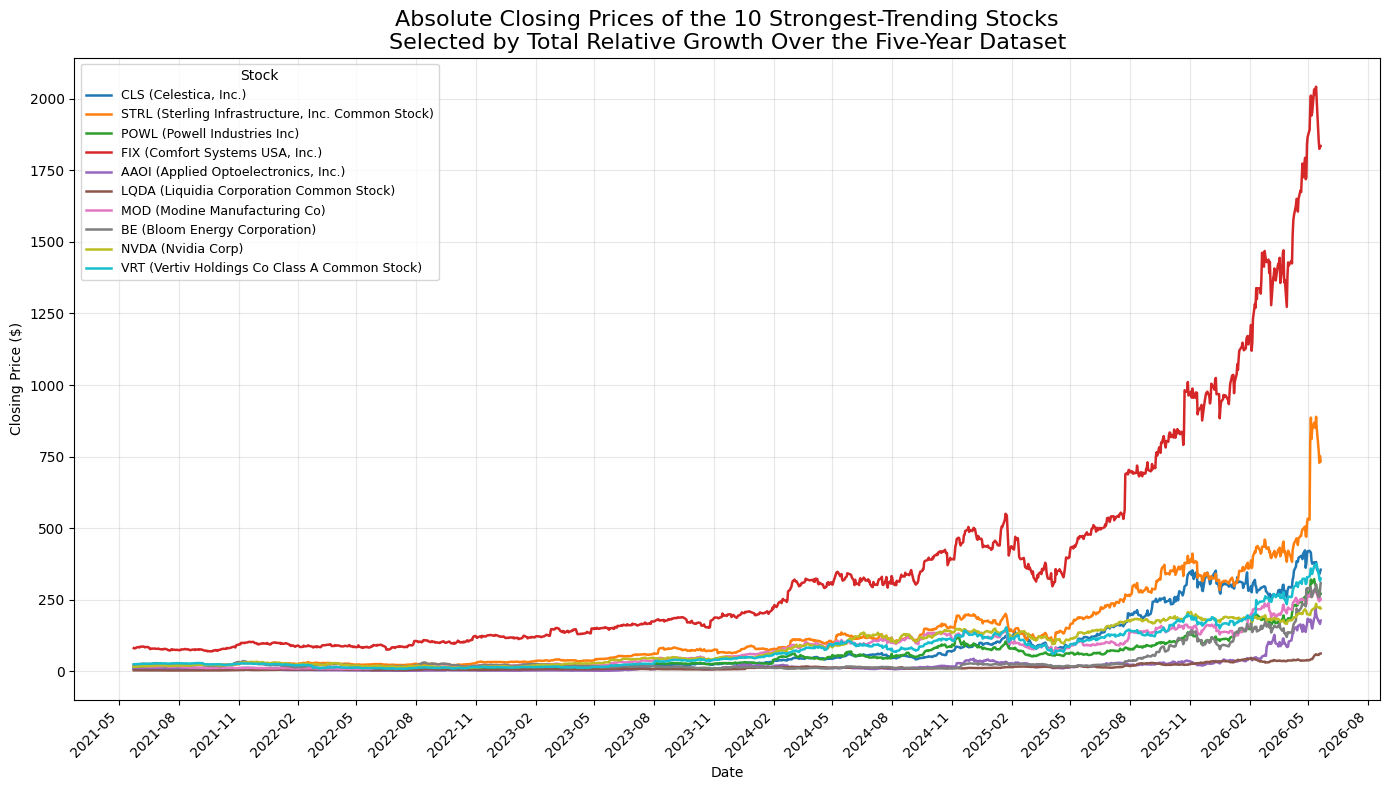

In [68]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Prepare data
market_cap_df = df_daily_5_yr[df_daily_5_yr['market_cap'] > 5000000000]
master_df = market_cap_df.copy()
master_df['timestamp'] = pd.to_datetime(master_df['timestamp'])
master_df = master_df.sort_values(['ticker', 'timestamp'])

# Find the final date in the dataset
latest_date = master_df['timestamp'].max()

# Get each stock's row on the final date
recent_day_df = master_df[
    master_df['timestamp'] == latest_date
].copy()

# Select the 10 stocks with the greatest relative growth
strongest_df = recent_day_df.nlargest(
    10,
    'close_pct_of_day1'
)

plot_stocks = strongest_df['ticker'].tolist()

# Create ticker-to-company-name dictionary
ticker_to_name = (
    master_df[['ticker', 'name']]
    .drop_duplicates(subset='ticker')
    .set_index('ticker')['name']
    .to_dict()
)

# Create figure
fig, ax = plt.subplots(figsize=(14, 8))

# Plot absolute closing prices
for stock in plot_stocks:
    stock_df = master_df[
        master_df['ticker'] == stock
    ].sort_values('timestamp')

    ax.plot(
        stock_df['timestamp'],
        stock_df['close'],
        label=f'{stock} ({ticker_to_name.get(stock, "Unknown")})',
        linewidth=1.8
    )

# Labels and title
ax.set_xlabel('Date')
ax.set_ylabel('Closing Price ($)')
ax.set_title(
    'Absolute Closing Prices of the 10 Strongest-Trending Stocks\n'
    'Selected by Total Relative Growth Over the Five-Year Dataset',
    fontsize=16
)

# Format dates
ax.xaxis.set_major_locator(
    mdates.MonthLocator(interval=3)
)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter('%Y-%m')
)

plt.setp(
    ax.get_xticklabels(),
    rotation=45,
    ha='right'
)

# Legend and grid
ax.legend(
    title='Stock',
    loc='best',
    fontsize=9
)

ax.grid(alpha=0.3)

fig.tight_layout()

# Save image
fig.savefig(
    'v15_overall_improvement_top10_marcap.png',
    dpi=300,
    bbox_inches='tight'
)

# Display image
plt.show()